# Loan Default Prediction System
## An End-to-End Machine Learning Project

### Predicting Loan Repayment Risk Using Machine Learning

**Made by**:  Vaidehi Bankar

# 📖 Executive Summary

Financial institutions approve thousands of loan applications every day. One of the biggest challenges they face is identifying applicants who are likely to default on their loans. Incorrect lending decisions can result in significant financial losses and increased operational risks.

This project develops a Machine Learning model to predict whether a loan applicant is likely to repay or default based on historical loan application data.

The project follows the complete Machine Learning lifecycle from data preprocessing to model evaluation and business insights.

# 💼 Business Problem

Banks and financial institutions receive numerous loan applications every day.

Approving every applicant without proper risk assessment may result in significant financial losses due to loan defaults.

On the other hand, rejecting too many applicants reduces business opportunities and customer satisfaction.

The challenge is to develop an intelligent system that can accurately distinguish between applicants who are likely to repay their loans and those who are at a higher risk of default.

An effective prediction system helps financial institutions:

- Reduce financial risk
- Improve loan approval decisions
- Increase profitability
- Enhance customer trust
- Automate the loan screening process

# Business Objective

The main objectives of this project are:

- Predict loan repayment risk.
- Reduce financial losses due to defaults.
- Assist banks in making data-driven lending decisions.
- Compare multiple machine learning models.
- Select the best-performing model.

# Dataset Description

The dataset contains historical loan application records.

### Target Variable

**Loan_Status**

- **Y** → Loan Approved
- **N** → Loan Rejected

### Features

- Gender
- Married
- Dependents
- Education
- Self_Employed
- ApplicantIncome
- CoapplicantIncome
- LoanAmount
- Loan_Amount_Term
- Credit_History
- Property_Area

In [1]:
!pip -q install shap

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Model Saving
import joblib

# Explainable AI
import shap

import warnings
warnings.filterwarnings("ignore")

In [3]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print(f"Random Seed Set to {RANDOM_STATE}")

Random Seed Set to 42


In [4]:
from google.colab import files

uploaded = files.upload()

Saving loan_data.csv to loan_data (3).csv


In [5]:
# Load the dataset

df = pd.read_csv("loan_data.csv")

In [6]:
# Display first five records

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [7]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 614
Number of Columns : 13


This is a structured tabular dataset suitable for solving a **supervised binary classification** problem

In [8]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [10]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [11]:
df.describe(include='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [12]:
# Display the names of numerical and categorical columns

categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(exclude='object').columns.tolist()

print("Categorical Features:")
print(categorical_cols)

print("\nNumerical Features:")
print(numerical_cols)

Categorical Features:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

Numerical Features:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


In [13]:
# Check missing values

missing_values = df.isnull().sum()

missing_values

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [14]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage.round(2)
})

,Missing Values,Percentage
Loan_ID,0,0.00
Gender,13,2.12
Married,3,0.49
Dependents,15,2.44
Education,0,0.00
Self_Employed,32,5.21
ApplicantIncome,0,0.00
CoapplicantIncome,0,0.00
LoanAmount,22,3.58
Loan_Amount_Term,14,2.28


In [15]:
# Check duplicate rows

duplicate_rows = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_rows}")

Duplicate Rows: 0


In [16]:
df.nunique().sort_values()

,0
Gender,2
Married,2
Self_Employed,2
Education,2
Loan_Status,2
Credit_History,2
Property_Area,3
Dependents,4
Loan_Amount_Term,10
LoanAmount,203


- Binary features have only two unique values.
- Identifier columns such as `Loan_ID` should contain unique values.
- Numerical features typically contain many unique values.

# Exploratory Data Analysis (EDA)

In [17]:
df["Loan_Status"].value_counts()

,count
Loan_Status,
Y,422
N,192


In [18]:
df["Loan_Status"].value_counts(normalize=True) * 100

,proportion
Loan_Status,
Y,68.729642
N,31.270358


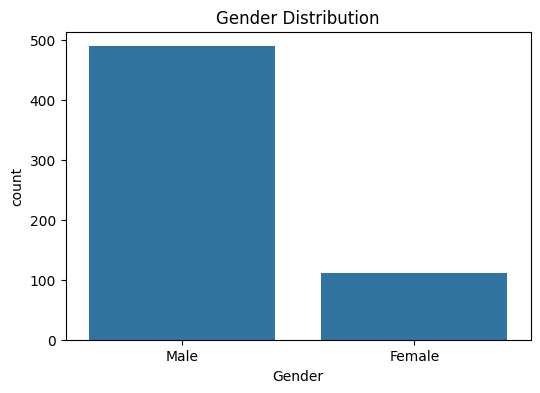

Gender
Male      489
Female    112
Name: count, dtype: int64
--------------------------------------------------


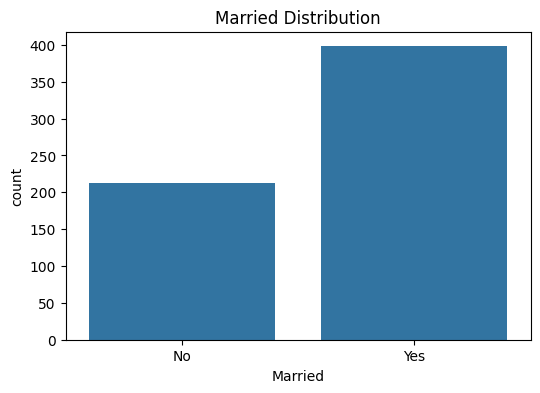

Married
Yes    398
No     213
Name: count, dtype: int64
--------------------------------------------------


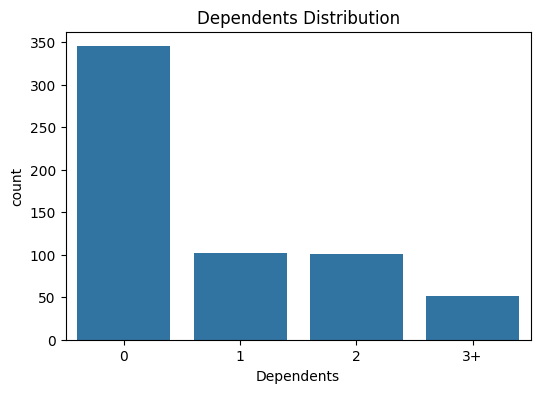

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64
--------------------------------------------------


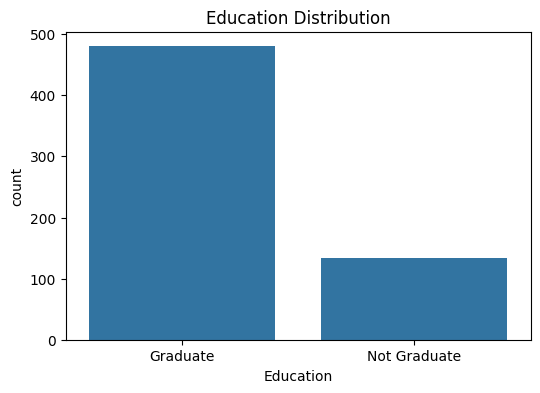

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64
--------------------------------------------------


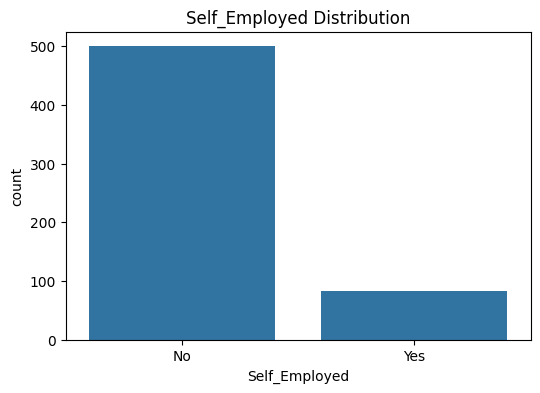

Self_Employed
No     500
Yes     82
Name: count, dtype: int64
--------------------------------------------------


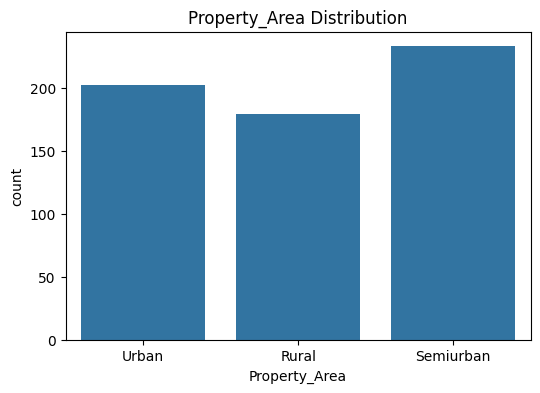

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64
--------------------------------------------------


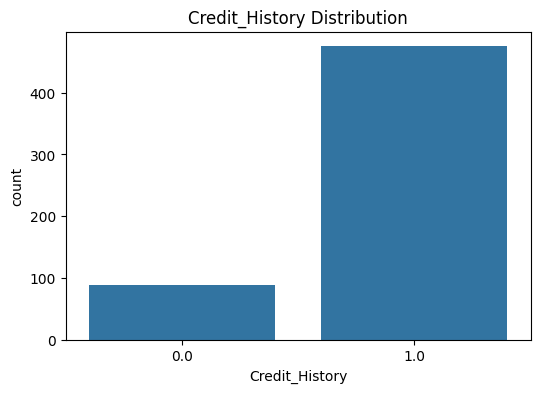

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64
--------------------------------------------------


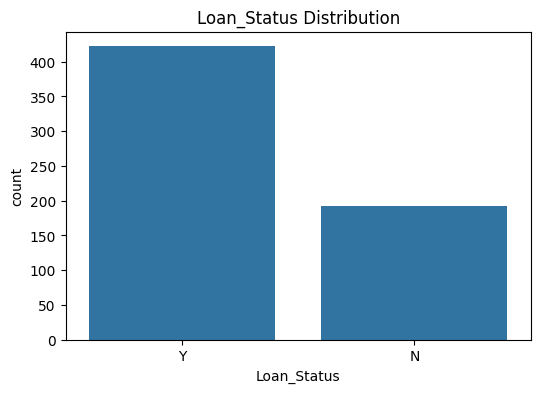

Loan_Status
Y    422
N    192
Name: count, dtype: int64
--------------------------------------------------


In [67]:
categorical_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Credit_History",
    "Loan_Status"
]

for feature in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=feature)
    plt.title(f"{feature} Distribution")
    plt.show()

    print(df[feature].value_counts())
    print("-"*50)

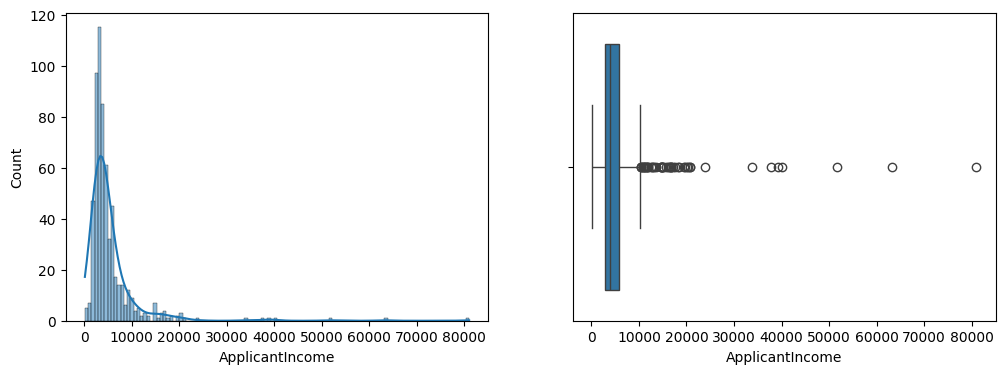

count      614.000000
mean      5403.459283
std       6109.041673
min        150.000000
25%       2877.500000
50%       3812.500000
75%       5795.000000
max      81000.000000
Name: ApplicantIncome, dtype: float64


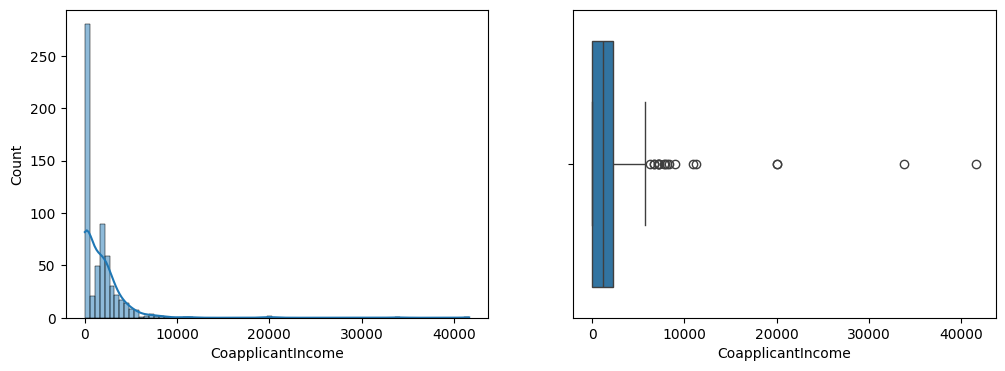

count      614.000000
mean      1621.245798
std       2926.248369
min          0.000000
25%          0.000000
50%       1188.500000
75%       2297.250000
max      41667.000000
Name: CoapplicantIncome, dtype: float64


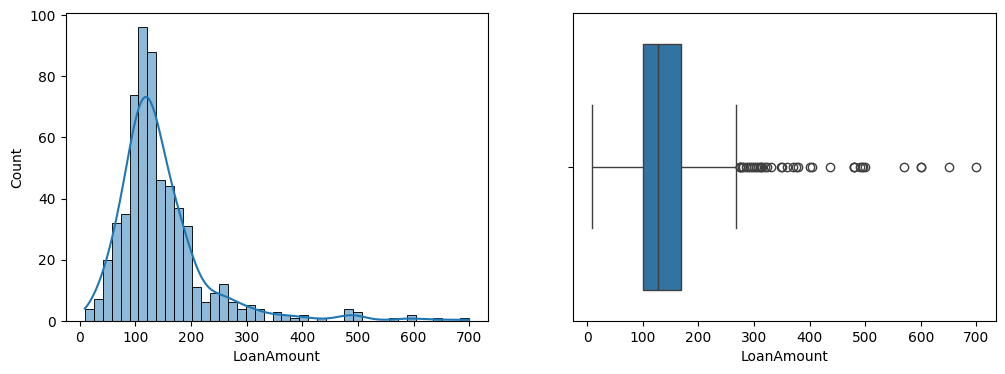

count    592.000000
mean     146.412162
std       85.587325
min        9.000000
25%      100.000000
50%      128.000000
75%      168.000000
max      700.000000
Name: LoanAmount, dtype: float64


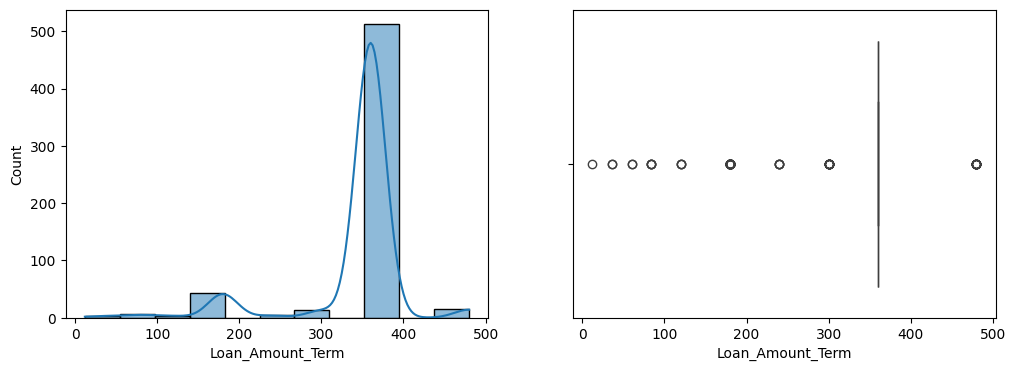

count    600.00000
mean     342.00000
std       65.12041
min       12.00000
25%      360.00000
50%      360.00000
75%      360.00000
max      480.00000
Name: Loan_Amount_Term, dtype: float64


In [68]:
numerical_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]

for feature in numerical_features:
    fig, ax = plt.subplots(1,2, figsize=(12,4))

    sns.histplot(df[feature], kde=True, ax=ax[0])
    sns.boxplot(x=df[feature], ax=ax[1])

    plt.show()

    print(df[feature].describe())

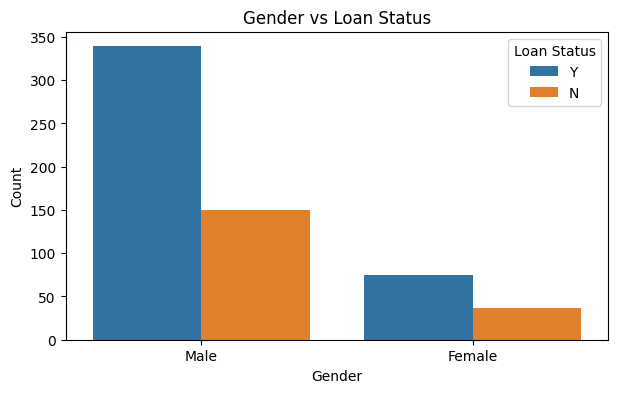

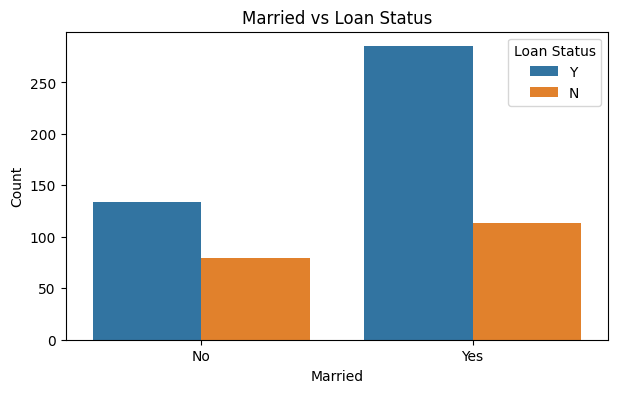

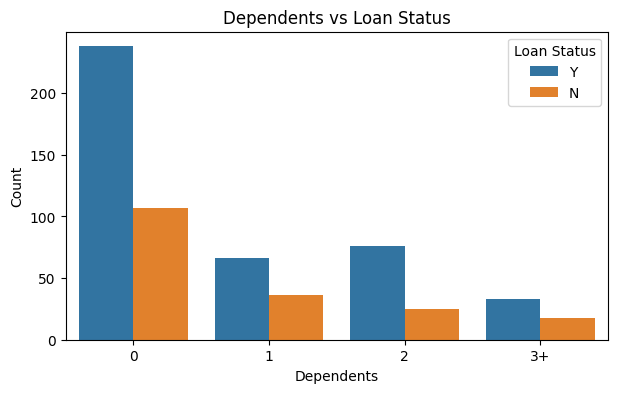

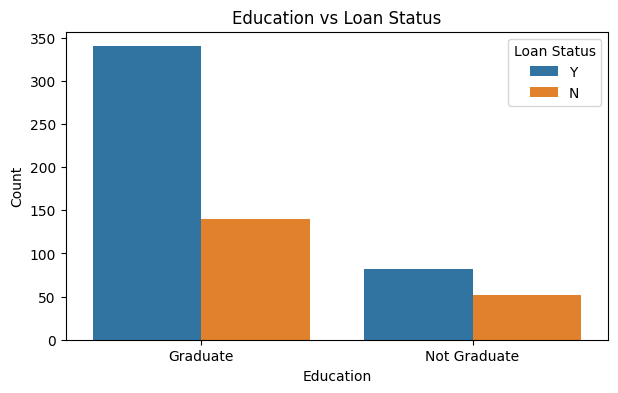

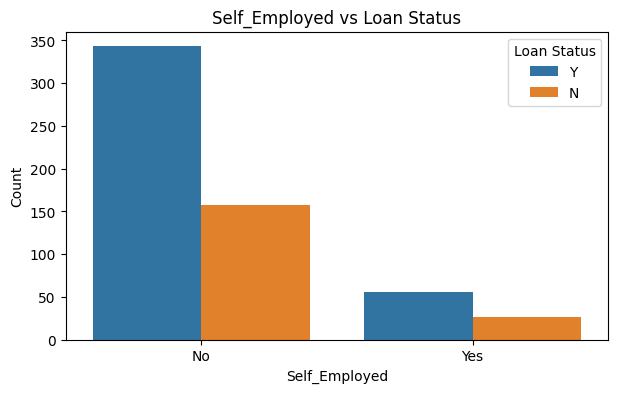

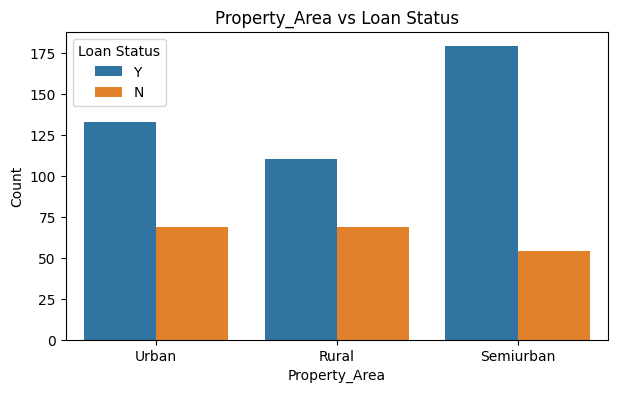

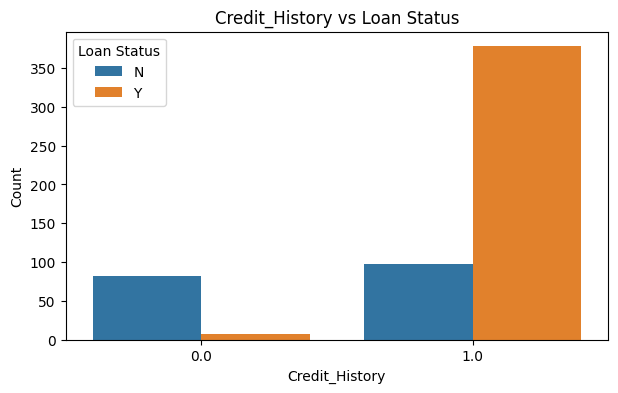

In [21]:
categorical_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Credit_History"
]

for feature in categorical_features:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df, x=feature, hue="Loan_Status")

    plt.title(f"{feature} vs Loan Status")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.legend(title="Loan Status")
    plt.show()

### Observations

- **Credit_History** shows the strongest relationship with loan approval. Applicants with a positive credit history are much more likely to have their loans approved.
- **Married** applicants appear to have a slightly higher approval rate than unmarried applicants.
- **Education**, **Gender**, and **Self_Employed** show relatively smaller differences between approved and rejected loans.
- **Property_Area** may influence approval, with some variation across Urban, Semiurban, and Rural applicants.

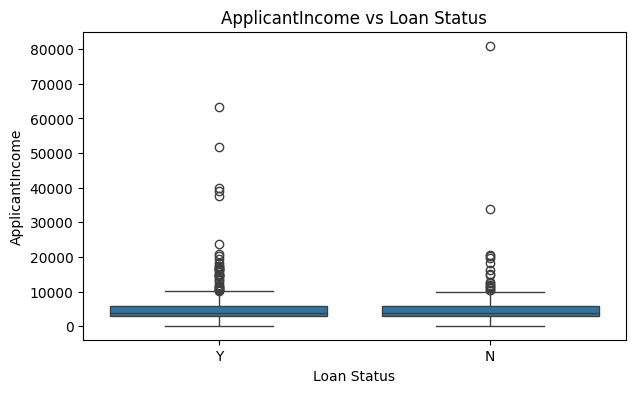

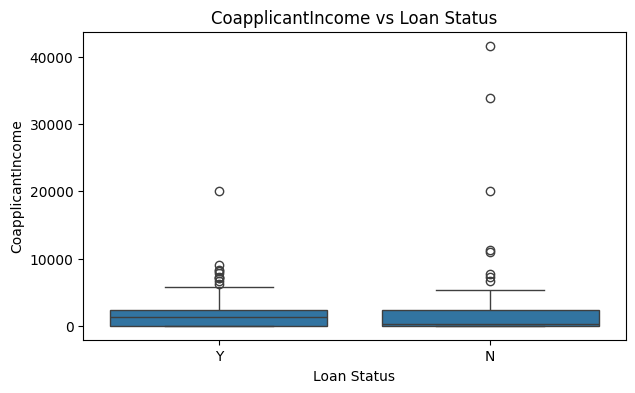

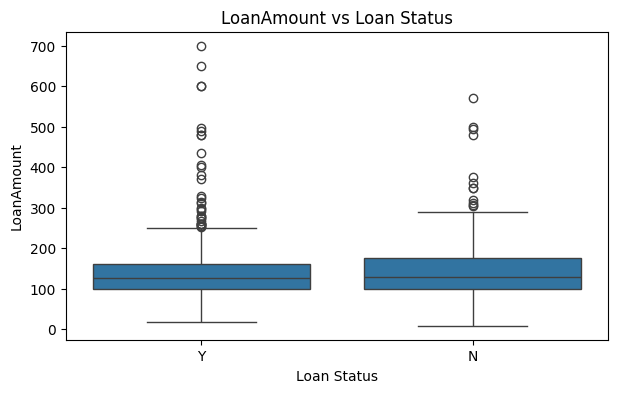

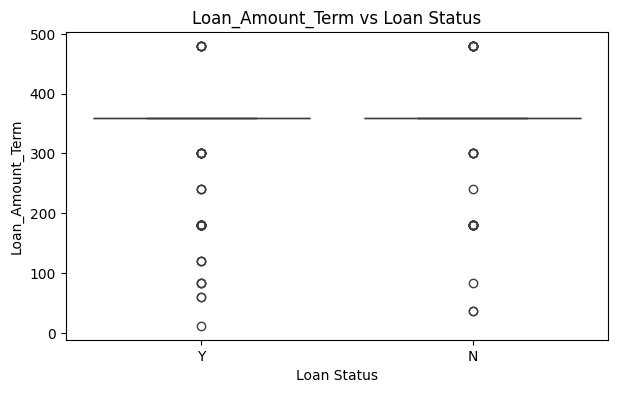

In [22]:
numerical_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]

for feature in numerical_features:
    plt.figure(figsize=(7,4))

    sns.boxplot(data=df, x="Loan_Status", y=feature)

    plt.title(f"{feature} vs Loan Status")
    plt.xlabel("Loan Status")
    plt.ylabel(feature)


    plt.show()

### Observations

- Most numerical features contain outliers, especially **ApplicantIncome** and **LoanAmount**.
- Loan approval cannot be determined solely by income, as both approved and rejected applicants have overlapping income ranges.
- The variation in **LoanAmount** suggests that loan size alone is not the deciding factor.
- These observations indicate that multiple features together contribute to loan approval rather than any single numerical feature.

# 2.4 Correlation Analysis

Correlation analysis helps us understand the linear relationships between numerical features.

A correlation heatmap can reveal whether two variables are strongly related, which is useful for identifying redundancy and understanding feature interactions.

In [23]:
# Create a temporary encoded target for analysis

df_corr = df.copy()
df_corr["Loan_Status"] = df_corr["Loan_Status"].map({"Y": 1, "N": 0})

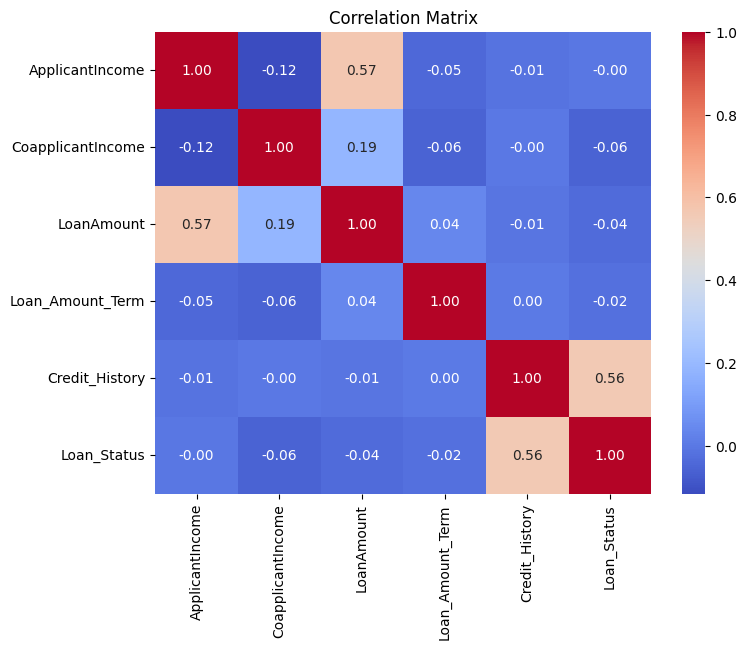

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df_corr.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### Observations

- Most numerical features have weak to moderate correlations with one another.
- **Credit_History** is expected to show the strongest positive relationship with `Loan_Status`.
- No pair of numerical features appears to exhibit severe multicollinearity.
- Correlation measures only linear relationships, so machine learning models may still capture additional non-linear patterns.

`Loan_ID` is a unique identifier and does not contribute to predicting loan approval. Removing it prevents the model from learning meaningless patterns.

In [25]:
# Remove Loan_ID as it is only an identifier

df.drop("Loan_ID", axis=1, inplace=True)

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [26]:
# Fill categorical columns with mode

categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed",
    "Credit_History"
]

for column in categorical_columns:
    df[column].fillna(df[column].mode()[0], inplace=True)


# Fill numerical columns with median

numerical_columns = [
    "LoanAmount",
    "Loan_Amount_Term"
]

for column in numerical_columns:
    df[column].fillna(df[column].median(), inplace=True)

All missing values have been successfully handled.

- Categorical features were filled using the **mode** because it represents the most frequent category.
- Numerical features were filled using the **median**, which is more robust to outliers than the mean.

In [27]:
# Convert categorical variables into numerical values

## Label Encoding
label_encoder = LabelEncoder()

# Binary categorical features
binary_features = [
    "Gender",
    "Married",
    "Education",
    "Self_Employed",
    "Loan_Status"
]

for feature in binary_features:
    df[feature] = label_encoder.fit_transform(df[feature])

df.head()

# One-Hot Encoding for multi-category features

multi_category_features = [
    "Dependents",
    "Property_Area"
]

df = pd.get_dummies(
    df,
    columns=multi_category_features,
    drop_first=True,
    dtype=int
)

df.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,5849,0.0,128.0,360.0,1.0,1,0,0,0,0,1
1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,1,0,0,0,0
2,1,1,0,1,3000,0.0,66.0,360.0,1.0,1,0,0,0,0,1
3,1,1,1,0,2583,2358.0,120.0,360.0,1.0,1,0,0,0,0,1
4,1,0,0,0,6000,0.0,141.0,360.0,1.0,1,0,0,0,0,1


### Observation

- Binary categorical variables were converted using **Label Encoding**.
- Features with more than two categories were transformed using **One-Hot Encoding**.
- Using `drop_first=True` helps avoid the dummy variable trap by removing one category from each encoded feature.

In [28]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

Feature Matrix Shape : (614, 14)
Target Vector Shape  : (614,)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (491, 14)
Testing Set  : (123, 14)


The dataset has been divided into:

- **80% Training Data** – Used to train the model.
- **20% Testing Data** – Used to evaluate the model on unseen data.

Using `stratify=y` ensures that the class distribution remains consistent in both the training and testing datasets.

**Feature scaling** standardizes numerical features so they have a mean of 0 and a standard deviation of 1.

In [30]:
scaler = StandardScaler()

numerical_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]

X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])

X_test[numerical_features] = scaler.transform(X_test[numerical_features])

In [31]:
X_train.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
154,1,0,0,0,-0.352802,-0.563228,-1.131588,0.280691,1.0,0,0,0,0,1
239,1,1,0,0,-0.343346,-0.563228,-0.592309,0.280691,1.0,1,0,0,1,0
448,1,1,0,0,-0.339471,0.050405,0.040758,0.280691,0.0,0,1,0,0,0
471,1,1,1,0,-0.445963,-0.024953,-0.393010,-2.486768,0.0,1,0,0,0,0
273,1,1,0,0,-0.451078,0.234495,0.040758,0.280691,1.0,0,0,0,1,0


# Part 4: Model Building

After preprocessing the data, we can now train machine learning models to predict loan approval.

The following classification algorithms will be used:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

These models are selected because they are widely used for binary classification problems and provide a good balance between interpretability and predictive performance.

In [32]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

### Train the models
for name, model in models.items():
    model.fit(X_train, y_train)

In [33]:
predictions = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test)

# Part 5: Model Evaluation

To compare the models fairly, we will use multiple evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- Classification Report

Using multiple metrics provides a more comprehensive assessment of model performance, especially when class distributions are not perfectly balanced.

In [34]:
results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.861789,0.84000,0.988235,0.908108
2,Random Forest,0.821138,0.83871,0.917647,0.876404
1,Decision Tree,0.731707,0.82500,0.776471,0.800000


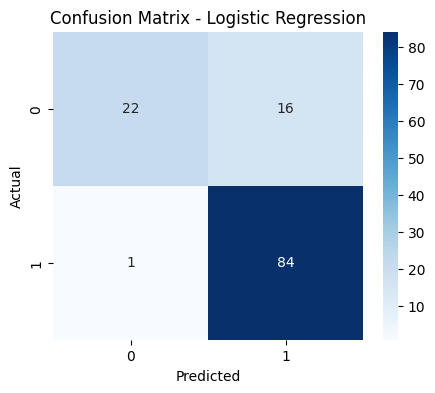

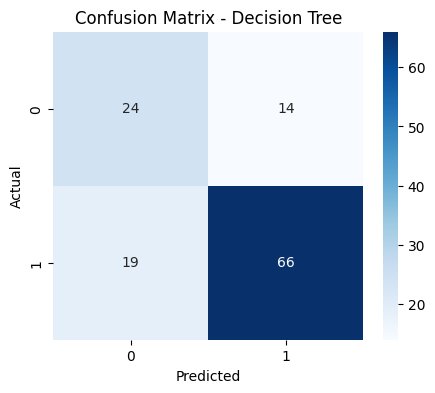

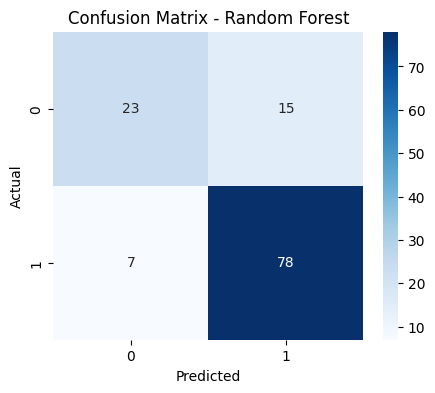

In [35]:
for name, model in models.items():

    plt.figure(figsize=(5,4))

    sns.heatmap(
        confusion_matrix(y_test, model.predict(X_test)),
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [36]:
for name, model in models.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(classification_report(
        y_test,
        model.predict(X_test)
    ))

Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123

Decision Tree
              precision    recall  f1-score   support

           0       0.56      0.63      0.59        38
           1       0.82      0.78      0.80        85

    accuracy                           0.73       123
   macro avg       0.69      0.70      0.70       123
weighted avg       0.74      0.73      0.74       123

Random Forest
              precision    recall  f1-score   support

           0       0.77      0.61      0.68        38
           1       0.84      0.92      0.88        85

    accuracy                           0.82       123
   macro avg       0.80      0.76      0.78       123
weighted avg       0.82   

## Model Comparison

Based on the evaluation metrics:

- Compare the accuracy, precision, recall, and F1-score of all three models.
- Consider not only the highest accuracy but also the balance between precision and recall.
- The best-performing model will be selected for further optimization.

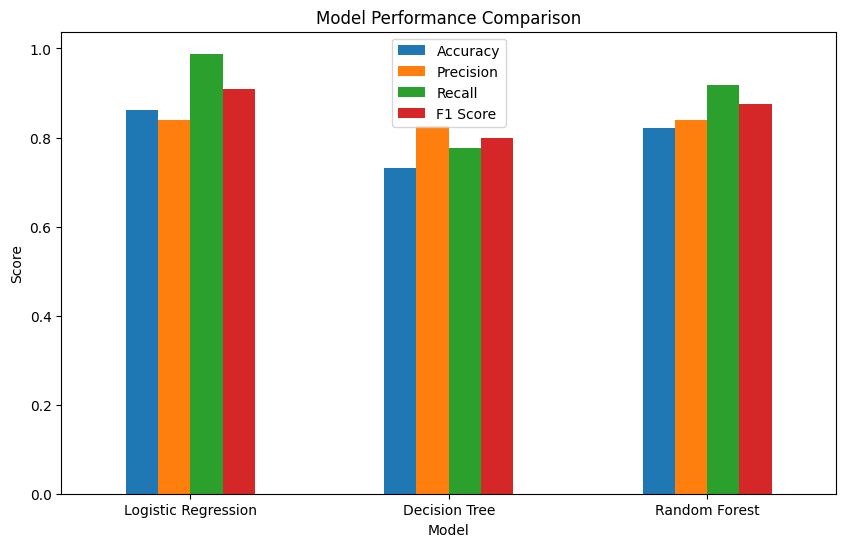

In [37]:
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

## Best Model Selection

After evaluating all three machine learning models, **Logistic Regression** achieved the best overall performance.

### Reasons

- Highest Accuracy
- Highest Recall
- Highest F1-Score
- Good Precision

Since Recall and F1-Score are particularly important for classification problems, Logistic Regression provides the best balance among all evaluation metrics.

Therefore, Logistic Regression is selected as the final model for further optimization.

# Part 6: Hyperparameter Tuning

Hyperparameter tuning helps improve model performance by searching for the best combination of parameters.

We will use **GridSearchCV** to evaluate multiple parameter combinations using cross-validation and select the best-performing Logistic Regression model.

In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='f1')

In [39]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best F1 Score : 0.8696016511867904


In [40]:
best_model = grid_search.best_estimator_

best_model

LogisticRegression(C=1, random_state=42, solver='liblinear')

Predict Using Best Model

In [41]:
y_pred_best = best_model.predict(X_test)

Final Evaluation

In [42]:
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

Accuracy : 0.8617886178861789
Precision: 0.84
Recall   : 0.9882352941176471
F1 Score : 0.9081081081081082


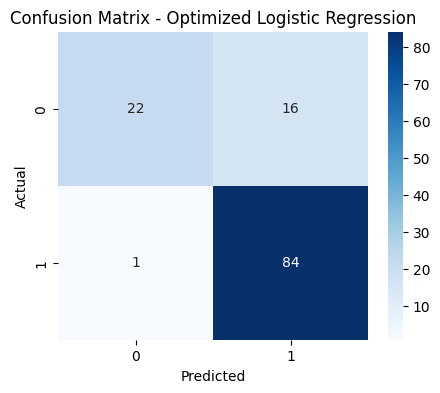

In [43]:
plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_best),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Optimized Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [44]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



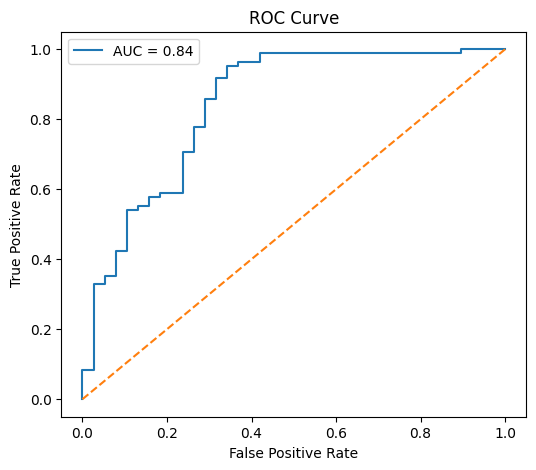

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

# Part 7: Feature Importance

In [46]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_model.coef_[0]
})

feature_importance["Absolute Coefficient"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute Coefficient
8,Credit_History,2.945376,2.945376
12,Property_Area_Semiurban,0.643683,0.643683
1,Married,0.483029,0.483029
2,Education,-0.395571,0.395571
10,Dependents_2,0.329082,0.329082
9,Dependents_1,-0.314272,0.314272
0,Gender,-0.282280,0.282280
3,Self_Employed,-0.205738,0.205738
5,CoapplicantIncome,-0.143507,0.143507
11,Dependents_3+,0.120240,0.120240


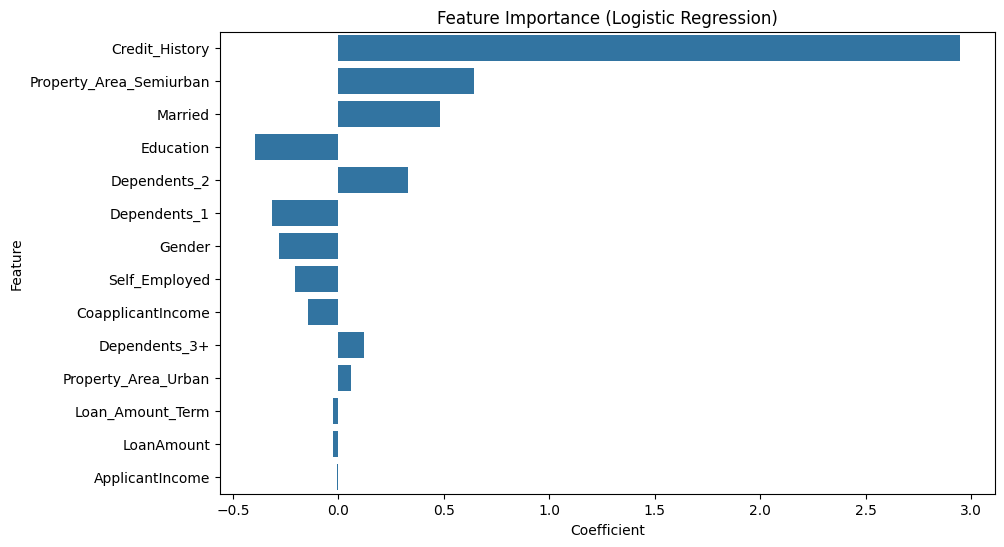

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

# Part 8: Building a Machine Learning Pipeline


In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

In [49]:
df = pd.read_csv("loan_data.csv")

In [50]:
df.drop("Loan_ID", axis=1, inplace=True)

In [51]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [52]:
categorical_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

numerical_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

In [53]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [54]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [55]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

In [56]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=grid_search.best_params_["C"],
        solver=grid_search.best_params_["solver"],
        penalty="l2",
        random_state=42
    ))
])

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Dependents', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area'])])),
                ('classifier',
                 LogisticRegression(C=1, random_state=42, solver='liblinear'))])

In [58]:
y_pred = pipeline.predict(X_test)

In [59]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="Y"))
print("Recall   :", recall_score(y_test, y_pred, pos_label="Y"))
print("F1 Score :", f1_score(y_test, y_pred, pos_label="Y"))

Accuracy : 0.8617886178861789
Precision: 0.84
Recall   : 0.9882352941176471
F1 Score : 0.9081081081081082


In [60]:
import joblib

joblib.dump(pipeline, "loan_prediction_pipeline.pkl")

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [61]:
loaded_pipeline = joblib.load("loan_prediction_pipeline.pkl")

In [63]:
def predict_loan(
    Gender,
    Married,
    Dependents,
    Education,
    Self_Employed,
    ApplicantIncome,
    CoapplicantIncome,
    LoanAmount,
    Loan_Amount_Term,
    Credit_History,
    Property_Area
):

    applicant = pd.DataFrame({
        "Gender":[Gender],
        "Married":[Married],
        "Dependents":[Dependents],
        "Education":[Education],
        "Self_Employed":[Self_Employed],
        "ApplicantIncome":[ApplicantIncome],
        "CoapplicantIncome":[CoapplicantIncome],
        "LoanAmount":[LoanAmount],
        "Loan_Amount_Term":[Loan_Amount_Term],
        "Credit_History":[Credit_History],
        "Property_Area":[Property_Area]
    })

    prediction = loaded_pipeline.predict(applicant)[0]

    print("Prediction:", prediction)

    if prediction=="Y":
        print("Loan Approved")
    else:
        print("Loan Rejected")

In [64]:
predict_loan(
    "Male",
    "Yes",
    "0",
    "Graduate",
    "No",
    5000,
    2000,
    120,
    360,
    1,
    "Urban"
)

Prediction: Y
Loan Approved
